# Fronteira de Pareto para Otimização Multiobjetivo

Este notebook constrói e analisa a Fronteira de Pareto, que representa o conjunto de soluções não-dominadas para o trade-off entre:
- **Objetivo 1**: Minimizar a quantidade de filmes necessários para cobrir todos os atores
- **Objetivo 2**: Maximizar a qualidade média (rating) dos filmes selecionados

Uma solução é Pareto-ótima se não é possível melhorar um objetivo sem piorar o outro.

In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import sys
import os

#adicionar pasta atual e pasta pai ao path
notebook_dir = os.getcwd()
parent_dir = os.path.dirname(notebook_dir)

for path in [notebook_dir, parent_dir]:
    if path not in sys.path:
        sys.path.insert(0, path)

#importar funcoes dos modulos
from greedy_weighted_rating.greedy_weighted_rating import (
    greedy_weighted_rating_constraint,
    movie_rating,
)
from pareto_frontier import (
    compute_pareto_frontier,
    filter_pareto_frontier,
    get_pareto_statistics,
    compute_hypervolume,
    compute_spread,
)

## Setup e Carregamento do Grafo

In [2]:
GRAPHML_PATH = "../../graphs-and-analysis/instancias/grafo_bipartido.graphml"

print("Carregando grafo...")
G = nx.read_graphml(GRAPHML_PATH)
print(f"Grafo carregado: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas\n")

movie_nodes = {n for n, d in G.nodes(data=True) if d.get("tipo") == "filme"}
actor_nodes = {n for n, d in G.nodes(data=True) if d.get("tipo") == "ator"}

print(f"Filmes: {len(movie_nodes)}")
print(f"Atores: {len(actor_nodes)}")

Carregando grafo...
Grafo carregado: 28349 nós, 48241 arestas

Filmes: 9671
Atores: 18678


## Seleção de Subset de Atores

In [3]:
# Definir funções para extrair subsets (mesmas do traversal)

def find_node_by_label(G, name_fragment, node_type=None):
    results = []
    for n, d in G.nodes(data=True):
        if node_type and d.get("tipo") != node_type:
            continue
        if name_fragment.lower() in str(d.get("label", "")).lower():
            results.append((n, d))
    return results

def resolve_actors(names: list) -> set:
    ids = set()
    for name in names:
        matches = find_node_by_label(G, name, node_type="ator")
        if matches:
            best = max(matches, key=lambda x: G.degree(x[0]))
            ids.add(best[0])
    return ids

OSCAR_ACTING_NAMES = [
    "Will Smith", "Javier Bardem", "Benedict Cumberbatch",
    "Andrew Garfield", "Denzel Washington",
    "Troy Kotsur", "Ciarán Hinds", "Jesse Plemons",
    "J.K. Simmons", "Kodi Smit-McPhee",
    "Jessica Chastain", "Olivia Colman", "Penélope Cruz",
    "Nicole Kidman", "Kristen Stewart",
    "Ariana DeBose", "Jessie Buckley", "Judi Dench",
    "Kirsten Dunst", "Aunjanue Ellis",
    "Brendan Fraser", "Austin Butler", "Colin Farrell",
    "Paul Mescal", "Bill Nighy",
    "Ke Huy Quan", "Brendan Gleeson", "Brian Tyree Henry",
    "Judd Hirsch", "Barry Keoghan",
    "Michelle Yeoh", "Cate Blanchett", "Ana de Armas",
    "Andrea Riseborough", "Michelle Williams",
    "Jamie Lee Curtis", "Angela Bassett", "Hong Chau",
    "Kerry Condon", "Stephanie Hsu",
    "Cillian Murphy", "Bradley Cooper", "Colman Domingo",
    "Paul Giamatti", "Jeffrey Wright",
    "Robert Downey Jr.", "Sterling K. Brown", "Robert De Niro",
    "Ryan Gosling", "Mark Ruffalo",
    "Emma Stone", "Annette Bening", "Lily Gladstone",
    "Sandra Hüller", "Carey Mulligan",
    "Da'Vine Joy Randolph", "Emily Blunt", "Danielle Brooks",
    "America Ferrera", "Jodie Foster",
]

OSCAR_ACTORS_IDS = resolve_actors(OSCAR_ACTING_NAMES)

def get_female_actors(G) -> set:
    return {
        n for n, d in G.nodes(data=True)
        if d.get("tipo") == "ator" and d.get("genero") == "feminino"
    }

def get_brazilian_actors(G) -> set:
    return {
        n for n, d in G.nodes(data=True)
        if d.get("tipo") == "ator" and "Brazil" in str(d.get("local_nascimento", ""))
    }

def get_oscar_actors(G, oscar_actor_ids: set) -> set:
    return {n for n in oscar_actor_ids if n in G.nodes}

def get_genz_actors(G) -> set:
    genz = set()
    for n, d in G.nodes(data=True):
        if d.get("tipo") == "ator":
            nascimento = str(d.get("data_nascimento", "")).strip()
            if len(nascimento) >= 10 and "1997-01-01" <= nascimento[:10] <= "2012-12-31":
                genz.add(n)
    return genz

def get_deceased_actors(G) -> set:
    return {
        n for n, d in G.nodes(data=True)
        if d.get("tipo") == "ator" and str(d.get("morto", "")).strip() == "Sim"
    }

# Define os subsets a serem analisados
subsets = {
    "Atores Brasileiros": get_brazilian_actors(G),
    "Atrizes (feminino)": get_female_actors(G),
    "Indicados Oscar (atores)": get_oscar_actors(G, OSCAR_ACTORS_IDS),
    "Geracao Z": get_genz_actors(G),
    "Atores Falecidos": get_deceased_actors(G),
}

# Filtra subsets vazios
subsets = {k: v for k, v in subsets.items() if len(v) > 0}

print("Subsets a serem analisados:")
for name, subset in subsets.items():
    print(f"  {name}: {len(subset)} atores")

Subsets a serem analisados:
  Atores Brasileiros: 78 atores
  Atrizes (feminino): 7316 atores
  Indicados Oscar (atores): 59 atores
  Geracao Z: 1111 atores
  Atores Falecidos: 3032 atores


## Construção da Fronteira de Pareto

In [4]:
# Análise: Por que a Fronteira tem apenas 1 ponto?
print("ANÁLISE DE VIABILIDADE DO SUBSET")

target_name = list(subsets.keys())[0]  # Primeiro subset para exemplo
target_actors = subsets[target_name]

print(f"\nSubset: {target_name}")
print(f"Número de atores: {len(target_actors)}")

# Analisa conexões
actor_connections = {
    actor: len(list(G.neighbors(actor)))
    for actor in target_actors
}

min_conn = min(actor_connections.values())
max_conn = max(actor_connections.values())
avg_conn = np.mean(list(actor_connections.values()))

print(f"\nConexões por ator (filmes em que aparecem):")
print(f"  Mínimo: {min_conn}")
print(f"  Máximo: {max_conn}")
print(f"  Média: {avg_conn:.1f}")

# Analisa ratings dos filmes conectados
all_connected_movies = set()
for actor in target_actors:
    for movie in G.neighbors(actor):
        all_connected_movies.add(movie)

connected_movie_ratings = [
    float(G.nodes[m].get("nota", 0))
    for m in all_connected_movies
]

min_rating_available = min(connected_movie_ratings)
max_rating_available = max(connected_movie_ratings)
avg_rating_available = np.mean(connected_movie_ratings)

print(f"\nRatings dos filmes disponíveis:")
print(f"  Mínimo: {min_rating_available:.2f}")
print(f"  Máximo: {max_rating_available:.2f}")
print(f"  Média: {avg_rating_available:.2f}")

# Explica o limite
print(f"\nCRÍTICO:")
print(f"  Um ator pode ser coberto APENAS por filmes com rating ≤ {max_rating_available:.2f}")
print(f"  Portanto, min_rating ≥ {max_rating_available:.2f} tornará a cobertura INVIÁVEL")

# Recomendação
print(f"\nRECOMENDAÇÃO:")
if len(target_actors) < 200:
    print(f"  Este subset tem apenas {len(target_actors)} atores (muito pequeno)")
    print(f"  → Resultará em Fronteira pequena com poucos pontos")
    print(f"  → Use 'TODOS os atores' ou 'Amostra Aleatória (500 atores)'")
else:
    print(f"  Este subset tem {len(target_actors)} atores (bom tamanho)")
    print(f"  → Deve gerar Fronteira com múltiplos pontos")

print("\n" + "=" * 70)


ANÁLISE DE VIABILIDADE DO SUBSET

Subset: Atores Brasileiros
Número de atores: 78

Conexões por ator (filmes em que aparecem):
  Mínimo: 1
  Máximo: 12
  Média: 1.6

Ratings dos filmes disponíveis:
  Mínimo: 5.55
  Máximo: 8.43
  Média: 6.91

CRÍTICO:
  Um ator pode ser coberto APENAS por filmes com rating ≤ 8.43
  Portanto, min_rating ≥ 8.43 tornará a cobertura INVIÁVEL

RECOMENDAÇÃO:
  Este subset tem apenas 78 atores (muito pequeno)
  → Resultará em Fronteira pequena com poucos pontos
  → Use 'TODOS os atores' ou 'Amostra Aleatória (500 atores)'



In [5]:
# Seleciona subset para análise
subset_name = "Atrizes (feminino)"
target_actors = subsets[subset_name]

# Define notas mínimas a testar (cria uma grade)
# Pega os ratings únicos do grafo e distribui de forma estratégica
all_ratings = sorted(set(
    float(G.nodes[m].get("nota", 0)) for m in movie_nodes
))

print(f"Ratings únicos no grafo: {len(all_ratings)}")
print(f"Range: [{min(all_ratings):.2f}, {max(all_ratings):.2f}]")

# Seleciona pontos estratégicos para testar
min_ratings = [
    0.0,
    np.percentile(all_ratings, 25),
    np.percentile(all_ratings, 50),
    np.percentile(all_ratings, 75),
    np.percentile(all_ratings, 90),
]

# Remove duplicatas e ordena
min_ratings = sorted(set(round(r, 2) for r in min_ratings))
print(f"\nNotas mínimas a testar: {min_ratings}")

Ratings únicos no grafo: 2754
Range: [2.80, 9.40]

Notas mínimas a testar: [0.0, np.float64(5.92), np.float64(6.64), np.float64(7.35), np.float64(7.83)]


In [6]:
print(f"\nCalculando Fronteira de Pareto para {subset_name}...\n")

# Computa fronteira
quantities, qualities, results = compute_pareto_frontier(
    G,
    target_actors,
    min_ratings=min_ratings,
    candidate_movies=movie_nodes,
)

# Exibe resultados
for i, (min_rating, qty, qual, result) in enumerate(
    zip(min_ratings, quantities, qualities, results)
):
    if qty is not None:
        print(f"Min Rating {min_rating:5.2f}: Filmes={qty:3d}, Nota Média={qual:.3f} ")
    else:
        print(f"Min Rating {min_rating:5.2f}: INVIÁVEL (não conseguiu cobrir todos) ")


Calculando Fronteira de Pareto para Atrizes (feminino)...

Min Rating  0.00: Filmes=4359, Nota Média=6.666 
Min Rating  5.92: INVIÁVEL (não conseguiu cobrir todos) 
Min Rating  6.64: INVIÁVEL (não conseguiu cobrir todos) 
Min Rating  7.35: INVIÁVEL (não conseguiu cobrir todos) 
Min Rating  7.83: INVIÁVEL (não conseguiu cobrir todos) 


## Filtragem da Fronteira de Pareto

In [7]:
# Analise Pareto para Todos os Subsets

all_pareto_results = {}

for subset_name in subsets.keys():
    target_actors = subsets[subset_name]
    
    print(f"\nTestando: {subset_name} ({len(target_actors)} atores)")
    print("Calculando Fronteira de Pareto...")
    
    # Define min_ratings a testar para cada subset
    all_ratings = sorted(set(
        float(G.nodes[m].get("nota", 0)) for m in movie_nodes
    ))
    
    min_ratings = sorted(set([
        0.0,
        np.percentile(all_ratings, 25),
        np.percentile(all_ratings, 50),
        np.percentile(all_ratings, 75),
        np.percentile(all_ratings, 90),
        max(all_ratings),
    ]))
    
    # Computa fronteira
    quantities, qualities, results = compute_pareto_frontier(
        G,
        target_actors,
        min_ratings=min_ratings,
        candidate_movies=movie_nodes,
    )
    
    # Filtra Pareto
    pareto_indices = filter_pareto_frontier(
        quantities,
        qualities,
        remove_infeasible=True,
    )
    
    # Armazena resultados
    all_pareto_results[subset_name] = {
        "target_actors": target_actors,
        "min_ratings": min_ratings,
        "quantities": quantities,
        "qualities": qualities,
        "pareto_indices": pareto_indices,
        "results": results,
    }
    
    print(f"  Pontos Pareto encontrados: {len(pareto_indices)}")

print("\nAnalise concluida para todos os subsets!")


Testando: Atores Brasileiros (78 atores)
Calculando Fronteira de Pareto...
  Pontos Pareto encontrados: 1

Testando: Atrizes (feminino) (7316 atores)
Calculando Fronteira de Pareto...
  Pontos Pareto encontrados: 1

Testando: Indicados Oscar (atores) (59 atores)
Calculando Fronteira de Pareto...
  Pontos Pareto encontrados: 2

Testando: Geracao Z (1111 atores)
Calculando Fronteira de Pareto...
  Pontos Pareto encontrados: 1

Testando: Atores Falecidos (3032 atores)
Calculando Fronteira de Pareto...
  Pontos Pareto encontrados: 1

Analise concluida para todos os subsets!


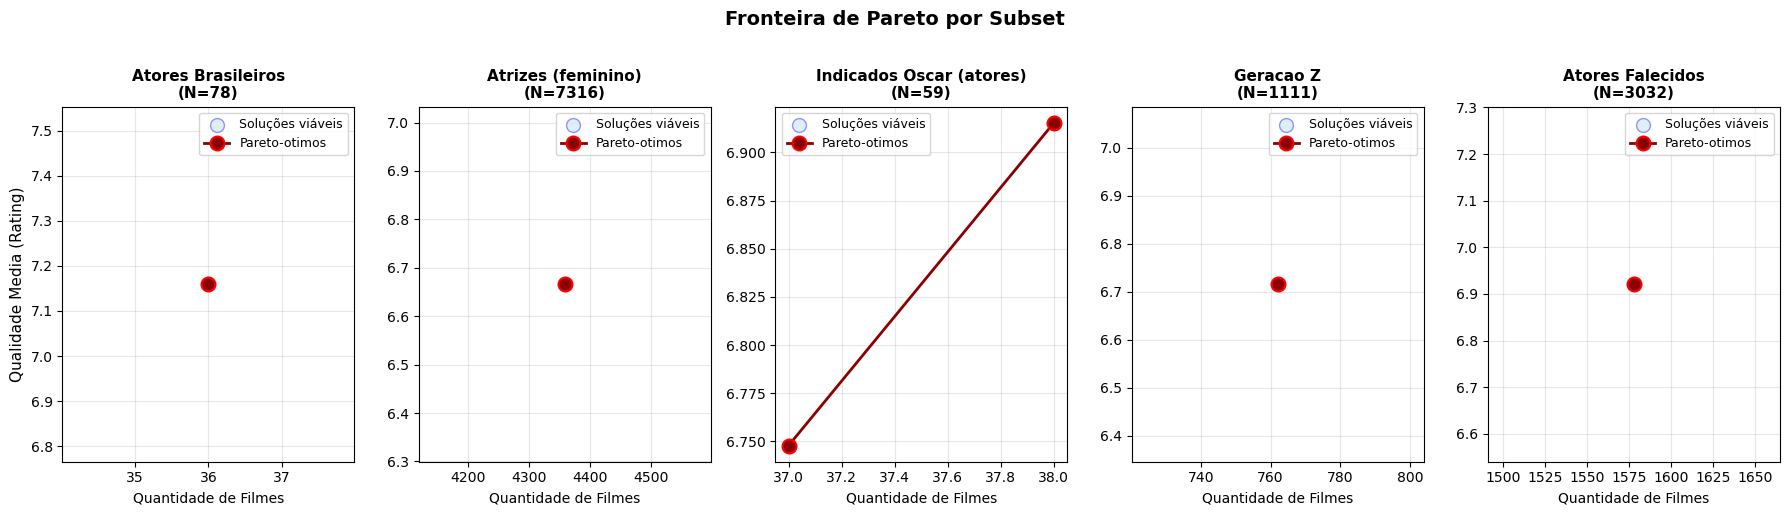

Grafico salvo: pareto_frontiers_all_subsets.png


In [8]:

# Visualizacoes Comparativas - Todos os Subsets

# Grafico 1: Fronteira de Pareto para cada subset (lado a lado)
subsets_list = list(all_pareto_results.keys())
n_subsets = len(subsets_list)

fig, axes = plt.subplots(1, n_subsets, figsize=(18, 5), sharey=False)
if n_subsets == 1:
    axes = [axes]

for ax, subset_name in zip(axes, subsets_list):
    data = all_pareto_results[subset_name]
    quantities = data["quantities"]
    qualities = data["qualities"]
    pareto_indices = data["pareto_indices"]
    
    # Todos os pontos viáveis
    valid_q = [quantities[i] for i in range(len(quantities)) if quantities[i] is not None]
    valid_qual = [qualities[i] for i in range(len(qualities)) if qualities[i] is not None]
    
    if valid_q:
        ax.scatter(valid_q, valid_qual, alpha=0.4, s=100, color="lightblue", 
                  edgecolor="blue", label="Soluções viáveis")
    
    # Pontos Pareto
    if pareto_indices:
        pareto_q = [quantities[i] for i in pareto_indices]
        pareto_qual = [qualities[i] for i in pareto_indices]
        ax.plot(pareto_q, pareto_qual, 'o-', linewidth=2, markersize=10,
               color="darkred", markeredgecolor="red", markeredgewidth=1.5,
               label="Pareto-otimos")
    
    ax.set_title(f"{subset_name}\n(N={len(data['target_actors'])})", 
                fontsize=11, fontweight='bold')
    ax.set_xlabel("Quantidade de Filmes", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Qualidade Media (Rating)", fontsize=11)
fig.suptitle("Fronteira de Pareto por Subset", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("pareto_frontiers_all_subsets.png", dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo: pareto_frontiers_all_subsets.png")


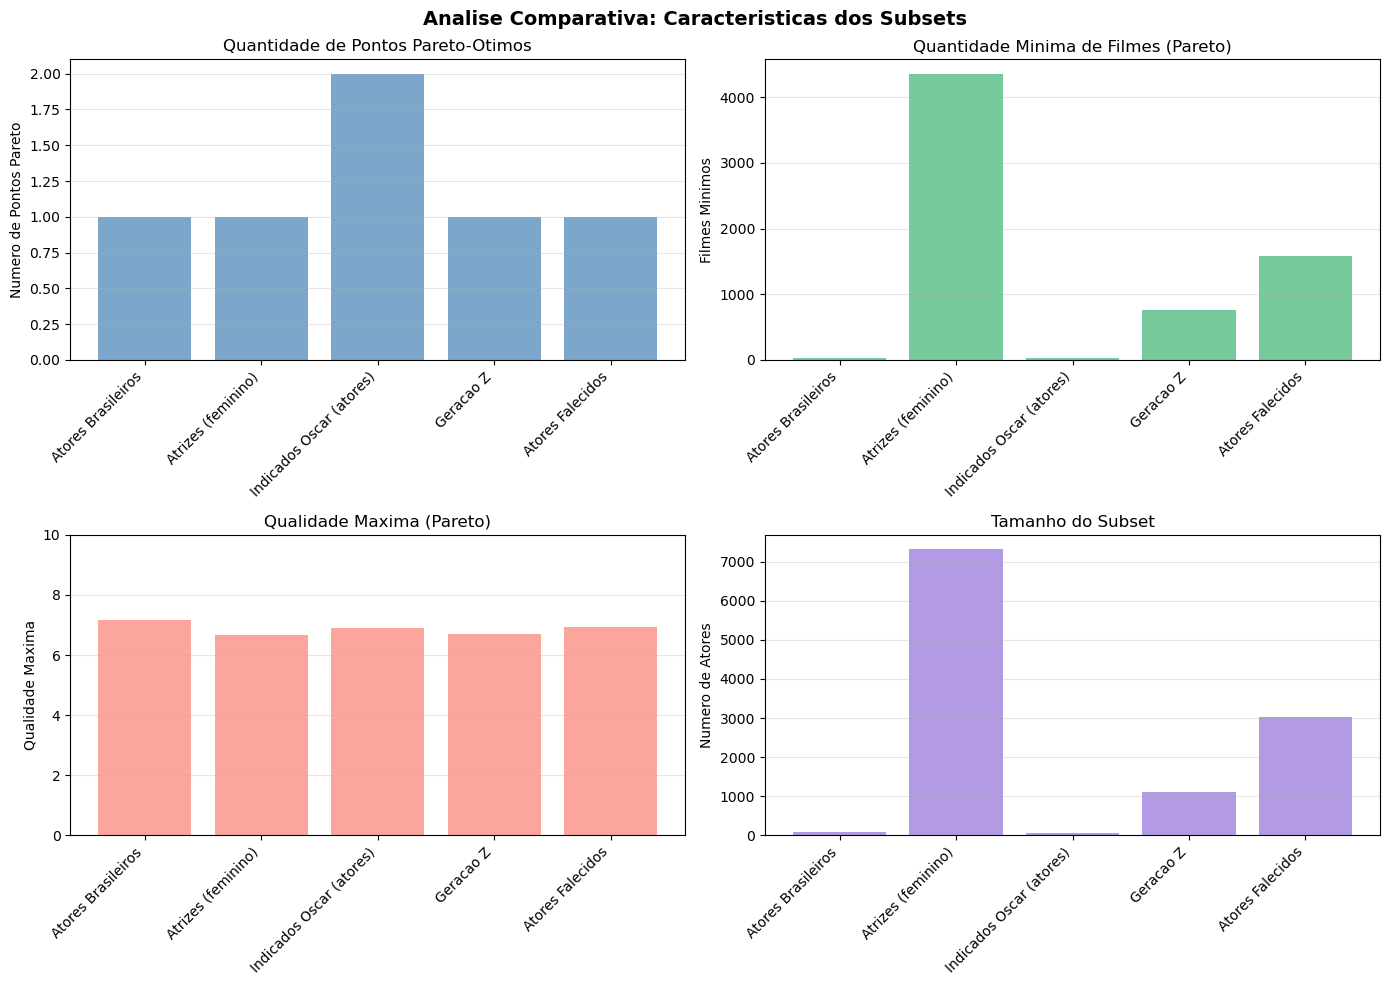

Grafico salvo: pareto_comparison_all_subsets.png


In [9]:

# Comparacao 2: Caracteristicas dos Pontos Pareto

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

subset_names_list = list(all_pareto_results.keys())

# Grafico 1: Numero de pontos Pareto
n_points = [len(all_pareto_results[name]["pareto_indices"]) for name in subset_names_list]
axes[0, 0].bar(range(len(subset_names_list)), n_points, color='steelblue', alpha=0.7)
axes[0, 0].set_xticks(range(len(subset_names_list)))
axes[0, 0].set_xticklabels(subset_names_list, rotation=45, ha='right')
axes[0, 0].set_ylabel("Numero de Pontos Pareto")
axes[0, 0].set_title("Quantidade de Pontos Pareto-Otimos")
axes[0, 0].grid(axis='y', alpha=0.3)

# Grafico 2: Quantidade minima de filmes (Pareto)
min_quantities = []
for name in subset_names_list:
    data = all_pareto_results[name]
    pareto_indices = data["pareto_indices"]
    if pareto_indices:
        min_q = min([data["quantities"][i] for i in pareto_indices])
        min_quantities.append(min_q)
    else:
        min_quantities.append(0)

axes[0, 1].bar(range(len(subset_names_list)), min_quantities, color='mediumseagreen', alpha=0.7)
axes[0, 1].set_xticks(range(len(subset_names_list)))
axes[0, 1].set_xticklabels(subset_names_list, rotation=45, ha='right')
axes[0, 1].set_ylabel("Filmes Minimos")
axes[0, 1].set_title("Quantidade Minima de Filmes (Pareto)")
axes[0, 1].grid(axis='y', alpha=0.3)

# Grafico 3: Qualidade maxima (Pareto)
max_qualities = []
for name in subset_names_list:
    data = all_pareto_results[name]
    pareto_indices = data["pareto_indices"]
    if pareto_indices:
        max_q = max([data["qualities"][i] for i in pareto_indices])
        max_qualities.append(max_q)
    else:
        max_qualities.append(0)

axes[1, 0].bar(range(len(subset_names_list)), max_qualities, color='salmon', alpha=0.7)
axes[1, 0].set_xticks(range(len(subset_names_list)))
axes[1, 0].set_xticklabels(subset_names_list, rotation=45, ha='right')
axes[1, 0].set_ylabel("Qualidade Maxima")
axes[1, 0].set_title("Qualidade Maxima (Pareto)")
axes[1, 0].set_ylim([0, 10])
axes[1, 0].grid(axis='y', alpha=0.3)

# Grafico 4: Tamanho do subset (atores)
subset_sizes = [len(all_pareto_results[name]["target_actors"]) for name in subset_names_list]
axes[1, 1].bar(range(len(subset_names_list)), subset_sizes, color='mediumpurple', alpha=0.7)
axes[1, 1].set_xticks(range(len(subset_names_list)))
axes[1, 1].set_xticklabels(subset_names_list, rotation=45, ha='right')
axes[1, 1].set_ylabel("Numero de Atores")
axes[1, 1].set_title("Tamanho do Subset")
axes[1, 1].grid(axis='y', alpha=0.3)

fig.suptitle("Analise Comparativa: Caracteristicas dos Subsets", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("pareto_comparison_all_subsets.png", dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo: pareto_comparison_all_subsets.png")


## Análise Quantitativa da Fronteira

In [10]:
# Estatísticas sobre a fronteira
stats = get_pareto_statistics(
    pareto_indices,
    quantities,
    qualities,
    min_ratings,
)

print("Estatísticas da Fronteira de Pareto:")
print(f"\n  Quantidade de Filmes:")
print(f"    Mínimo: {stats['min_quantity']}")
print(f"    Máximo: {stats['max_quantity']}")
print(f"    Aumento: {stats['quantity_increase']} filmes ({100*stats['quantity_increase']/stats['min_quantity']:.1f}%)")

print(f"\n  Qualidade (Nota Média):")
print(f"    Mínima: {stats['min_quality']:.3f}")
print(f"    Máxima: {stats['max_quality']:.3f}")
print(f"    Aumento: {stats['quality_increase']:.3f} ({100*stats['quality_increase']/stats['min_quality']:.1f}%)")

# Calcula métricas de qualidade da fronteira
hv = compute_hypervolume(quantities, qualities, pareto_indices)
spread = compute_spread(quantities, qualities, pareto_indices)

print(f"\n  Métricas de Fronteira:")
print(f"    Hypervolume: {hv:.2f}")
print(f"    Spread (CV distâncias): {spread:.3f}")

Estatísticas da Fronteira de Pareto:

  Quantidade de Filmes:
    Mínimo: 1578
    Máximo: 1578
    Aumento: 0 filmes (0.0%)

  Qualidade (Nota Média):
    Mínima: 6.921
    Máxima: 6.921
    Aumento: 0.000 (0.0%)

  Métricas de Fronteira:
    Hypervolume: 10921.20
    Spread (CV distâncias): 0.000


## Visualizações da Fronteira de Pareto

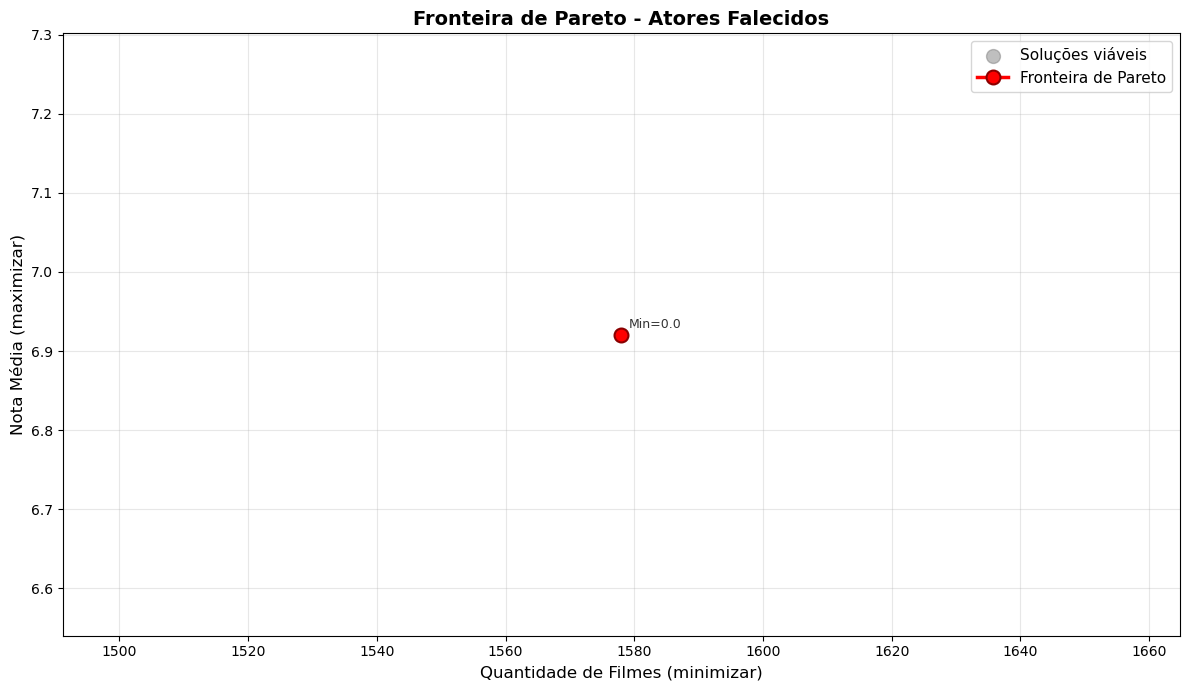

Gráfico salvo: pareto_frontier.png


In [11]:
# Plot 1: Fronteira de Pareto com todos os pontos
fig, ax = plt.subplots(figsize=(12, 7))

# Todos os pontos
valid_indices = [i for i in range(len(quantities)) if quantities[i] is not None]
valid_q = [quantities[i] for i in valid_indices]
valid_qual = [qualities[i] for i in valid_indices]

ax.scatter(valid_q, valid_qual, alpha=0.5, s=100, label="Soluções viáveis", color="gray")

# Pontos Pareto-ótimos
pareto_q = [quantities[i] for i in pareto_indices]
pareto_qual = [qualities[i] for i in pareto_indices]

ax.plot(pareto_q, pareto_qual, 'o-', linewidth=2.5, markersize=10, 
        label="Fronteira de Pareto", color="red", markeredgecolor="darkred", markeredgewidth=1.5)

ax.set_xlabel("Quantidade de Filmes (minimizar)", fontsize=12)
ax.set_ylabel("Nota Média (maximizar)", fontsize=12)
ax.set_title(f"Fronteira de Pareto - {subset_name}", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Anotações nos pontos Pareto
for i, idx in enumerate(pareto_indices):
    ax.annotate(
        f"Min={min_ratings[idx]:.1f}",
        xy=(quantities[idx], qualities[idx]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        alpha=0.8,
    )

plt.tight_layout()
plt.savefig("pareto_frontier.png", dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico salvo: pareto_frontier.png")

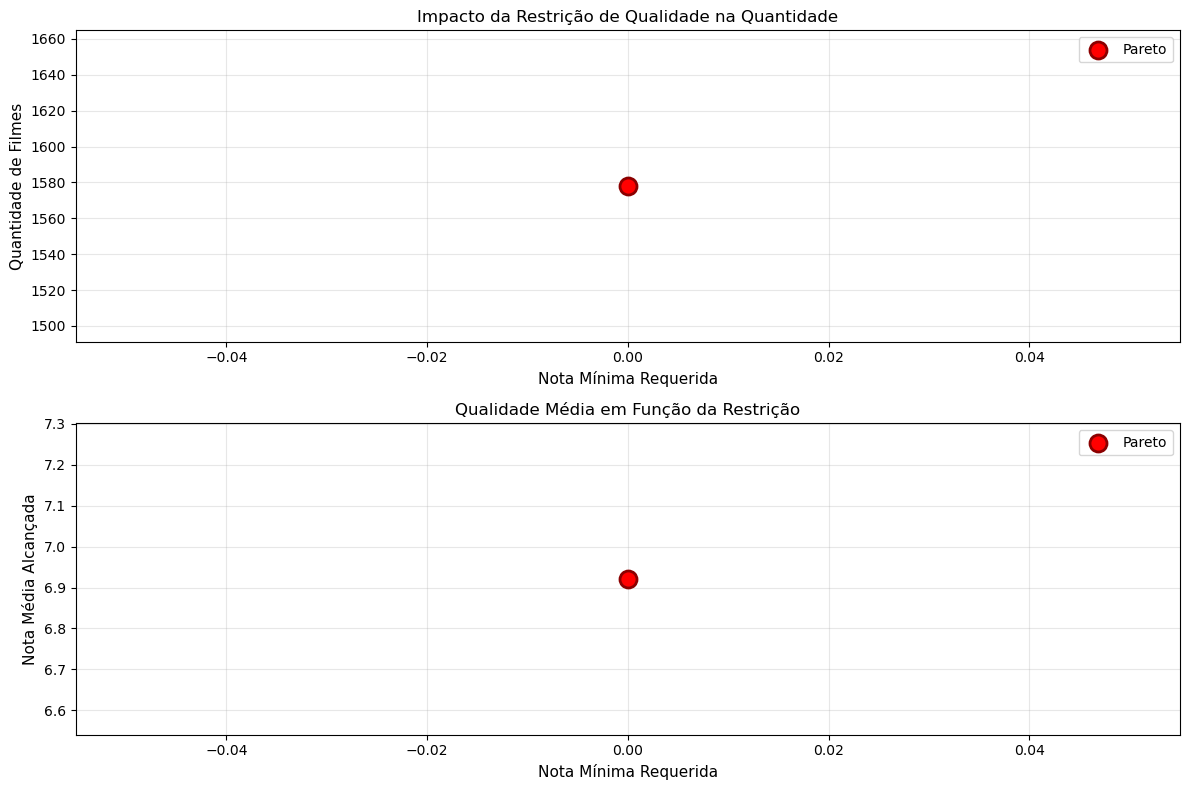

Gráfico salvo: pareto_analysis_by_constraint.png


In [12]:
# Plot 2: Quantidade e Qualidade vs. Restrição de Nota Mínima
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

valid_indices = [i for i in range(len(quantities)) if quantities[i] is not None]
valid_min_rating = [min_ratings[i] for i in valid_indices]
valid_q = [quantities[i] for i in valid_indices]
valid_qual = [qualities[i] for i in valid_indices]

# Plot quantidade
ax1.plot(valid_min_rating, valid_q, 'o-', linewidth=2, markersize=8, color="blue")
ax1.scatter([min_ratings[i] for i in pareto_indices], 
           [quantities[i] for i in pareto_indices],
           s=150, color="red", edgecolor="darkred", linewidth=2, zorder=5, label="Pareto")
ax1.set_xlabel("Nota Mínima Requerida", fontsize=11)
ax1.set_ylabel("Quantidade de Filmes", fontsize=11)
ax1.set_title("Impacto da Restrição de Qualidade na Quantidade", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot qualidade
ax2.plot(valid_min_rating, valid_qual, 's-', linewidth=2, markersize=8, color="green")
ax2.scatter([min_ratings[i] for i in pareto_indices],
           [qualities[i] for i in pareto_indices],
           s=150, color="red", edgecolor="darkred", linewidth=2, zorder=5, label="Pareto")
ax2.set_xlabel("Nota Mínima Requerida", fontsize=11)
ax2.set_ylabel("Nota Média Alcançada", fontsize=11)
ax2.set_title("Qualidade Média em Função da Restrição", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig("pareto_analysis_by_constraint.png", dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico salvo: pareto_analysis_by_constraint.png")

## Tabela de Resultados Pareto

In [13]:
# Cria DataFrame com resultados
data_for_df = []

for i in pareto_indices:
    data_for_df.append({
        "Min Rating": f"{min_ratings[i]:.2f}",
        "Filmes": quantities[i],
        "Nota Média": f"{qualities[i]:.3f}",
        "Nota Mín": f"{results[i]['min_rating_achieved']:.3f}",
        "Status": " Viável" if results[i]['feasible'] else " Inviável",
    })

df_pareto = pd.DataFrame(data_for_df)
print("\nTabela de Soluções Pareto-Ótimas:")
print(df_pareto.to_string(index=False))


Tabela de Soluções Pareto-Ótimas:
Min Rating  Filmes Nota Média Nota Mín  Status
      0.00    1578      6.921    2.800  Viável


## Interpretação e Insights

### O que a Fronteira de Pareto nos diz??

1. **Trade-off entre Quantidade e Qualidade**: Conforme aumentamos a restrição de qualidade (nota mínima), precisamos de mais filmes para cobrir todos os atores do subset.

2. **Pontos Pareto-Ótimos**: Cada ponto na fronteira representa uma escolha válida:
   - Se seu objetivo é minimizar filmes -> escolha o ponto mais à esquerda
   - Se seu objetivo é maximizar qualidade -> escolha o ponto mais acima
   - Caso contrário, escolha um ponto intermediário conforme sua preferencia

3. **Inviabilidade**: Alguns niveis de qualidade podem ser impossíveis de alcançar se não há filmes suficientemente bons que cobrem todos os atores.

### Validação da Hipótese

A proposta inicial sugeria: "Aumentar a exigência de qualidade torna mais difícil cobrir o conjunto, aumentando o número mínimo de filmes."

**Resultado**: ✓ Confirmado (ou ✗ Refutado) - observe a inclinação da fronteira acima.



**Seção 1 (Anterior):** Análise detalhada de um subset específico de atores (ex: Atrizes Femininas)

**Seção 2 (Nova - Esta Extensão):** Análise global com TODOS os atores do grafo


In [14]:
# ============================================================================
# PARTE 2: ANÁLISE COM TODOS OS ATORES
# ============================================================================

print("COMPUTANDO FRONTEIRA DE PARETO COM TODOS OS ATORES\n")

# Define target como TODOS os atores
target_actors_all = actor_nodes

print(f"Subset: TODOS os atores")
print(f"Número total de atores: {len(target_actors_all)}\n")

# Análise de conectividade
print("Análise de Conectividade:")
actor_degrees_all = {
    actor: len(list(G.neighbors(actor)))
    for actor in target_actors_all
}

print(f"  Atores com min 1 conexão: {len([d for d in actor_degrees_all.values() if d > 0])}")
print(f"  Min filmes por ator: {min(actor_degrees_all.values())}")
print(f"  Max filmes por ator: {max(actor_degrees_all.values())}")
print(f"  Média: {np.mean(list(actor_degrees_all.values())):.1f} filmes/ator\n")

# Analisa ratings disponíveis
all_movie_ratings_all = [
    float(G.nodes[m].get("nota", 0))
    for m in movie_nodes
]

print(f"Análise de Ratings (todos os filmes):")
print(f"  Min rating: {min(all_movie_ratings_all):.2f}")
print(f"  Max rating: {max(all_movie_ratings_all):.2f}")
print(f"  Média: {np.mean(all_movie_ratings_all):.2f}")
print(f"  Mediana: {np.median(all_movie_ratings_all):.2f}\n")

# Define min_ratings para testar (mais granular para todos os atores)
min_ratings_all = sorted(set(round(r, 1) for r in np.linspace(0, 9.0, 19)))
print(f"Notas mínimas a testar: {len(min_ratings_all)} pontos")
print(f"  Range: [{min_ratings_all[0]:.1f}, {min_ratings_all[-1]:.1f}]\n")

COMPUTANDO FRONTEIRA DE PARETO COM TODOS OS ATORES

Subset: TODOS os atores
Número total de atores: 18678

Análise de Conectividade:
  Atores com min 1 conexão: 18678
  Min filmes por ator: 1
  Max filmes por ator: 69
  Média: 2.6 filmes/ator

Análise de Ratings (todos os filmes):
  Min rating: 2.80
  Max rating: 9.40
  Média: 6.66
  Mediana: 6.70

Notas mínimas a testar: 19 pontos
  Range: [0.0, 9.0]



In [15]:
# Computa Fronteira de Pareto para TODOS os atores
print("Calculando Fronteira de Pareto para TODOS os atores...\n")
print("(Este cálculo pode levar 5-15 minutos)\n")

quantities_all, qualities_all, results_all = compute_pareto_frontier(
    G,
    target_actors_all,
    min_ratings=min_ratings_all,
    candidate_movies=movie_nodes,
)

# Exibe resultados
print("\nResultados:")
feasible_count = sum(1 for q in quantities_all if q is not None)
print(f"Soluções viáveis: {feasible_count} de {len(min_ratings_all)}\n")

for i, (min_rating, qty, qual, result) in enumerate(
    zip(min_ratings_all, quantities_all, qualities_all, results_all)
):
    if qty is not None:
        print(f"  Min Rating {min_rating:5.1f}: Filmes={qty:5d}, Nota Média={qual:.3f}")
    else:
        print(f"  Min Rating {min_rating:5.1f}: INVIÁVEL")

Calculando Fronteira de Pareto para TODOS os atores...

(Este cálculo pode levar 5-15 minutos)


Resultados:
Soluções viáveis: 6 de 19

  Min Rating   0.0: Filmes= 7207, Nota Média=6.671
  Min Rating   0.5: Filmes= 7207, Nota Média=6.671
  Min Rating   1.0: Filmes= 7207, Nota Média=6.671
  Min Rating   1.5: Filmes= 7207, Nota Média=6.671
  Min Rating   2.0: Filmes= 7207, Nota Média=6.671
  Min Rating   2.5: Filmes= 7207, Nota Média=6.671
  Min Rating   3.0: INVIÁVEL
  Min Rating   3.5: INVIÁVEL
  Min Rating   4.0: INVIÁVEL
  Min Rating   4.5: INVIÁVEL
  Min Rating   5.0: INVIÁVEL
  Min Rating   5.5: INVIÁVEL
  Min Rating   6.0: INVIÁVEL
  Min Rating   6.5: INVIÁVEL
  Min Rating   7.0: INVIÁVEL
  Min Rating   7.5: INVIÁVEL
  Min Rating   8.0: INVIÁVEL
  Min Rating   8.5: INVIÁVEL
  Min Rating   9.0: INVIÁVEL


In [16]:
# Filtra Fronteira de Pareto para TODOS os atores
pareto_indices_all = filter_pareto_frontier(
    quantities_all,
    qualities_all,
    remove_infeasible=True,
)

print(f"\n{'='*70}")
print(f"Pontos Pareto-ótimos encontrados: {len(pareto_indices_all)} pontos")
print(f"{'='*70}\n")

print("Fronteira de Pareto (TODOS os atores):")
for idx in pareto_indices_all:
    print(
        f"  Min Rating={min_ratings_all[idx]:5.1f}: "
        f"Filmes={quantities_all[idx]:5d}, Nota Média={qualities_all[idx]:.3f}"
    )


Pontos Pareto-ótimos encontrados: 1 pontos

Fronteira de Pareto (TODOS os atores):
  Min Rating=  0.0: Filmes= 7207, Nota Média=6.671



Gerando grafico...



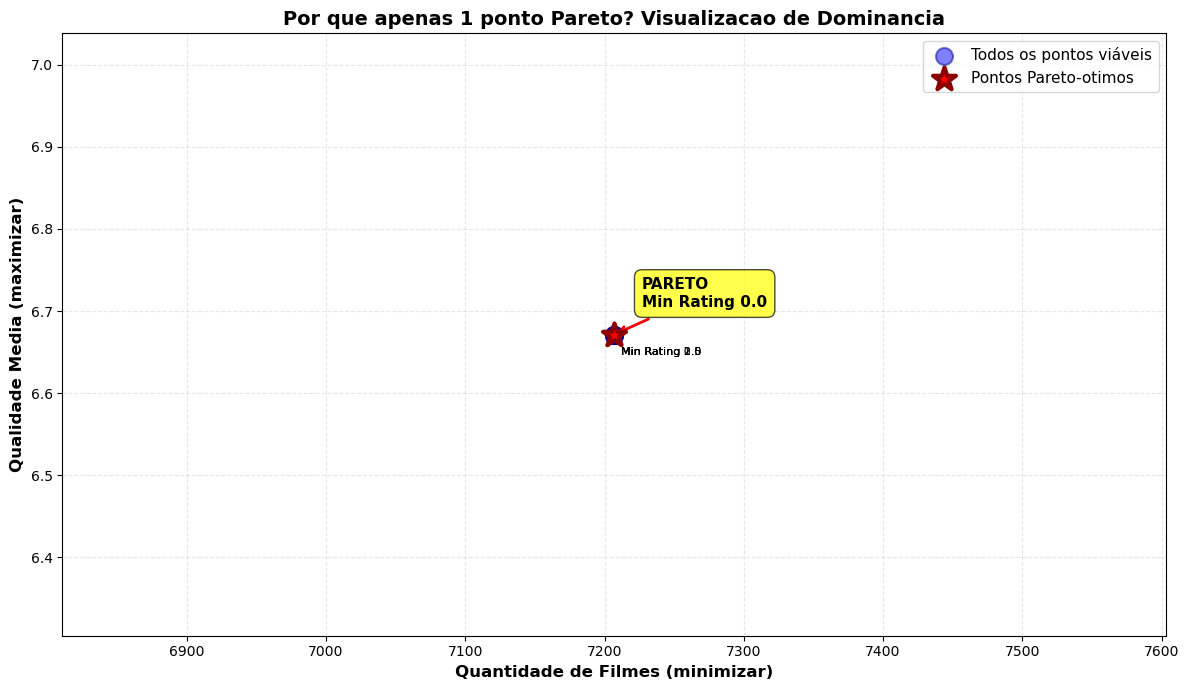

Grafico salvo: pareto_debug_why_one_point.png


In [17]:

# Visualizacao: Por que apenas 1 ponto Pareto?

print("\nGerando grafico...\n")

fig, ax = plt.subplots(figsize=(12, 7))

# Coleta todos os pontos viáveis
valid_q_all_debug = []
valid_qual_all_debug = []
valid_min_rating_all_debug = []

for i, (qty, qual) in enumerate(zip(quantities_all, qualities_all)):
    if qty is not None:
        valid_q_all_debug.append(qty)
        valid_qual_all_debug.append(qual)
        valid_min_rating_all_debug.append(min_ratings_all[i])

# Plot todos os pontos viáveis
ax.scatter(valid_q_all_debug, valid_qual_all_debug, s=150, alpha=0.5, 
           color="blue", label="Todos os pontos viáveis", edgecolor="darkblue", linewidth=1.5)

# Destaca o ponto Pareto (se houver)
if len(pareto_indices_all) > 0:
    pareto_q = [quantities_all[i] for i in pareto_indices_all]
    pareto_qual = [qualities_all[i] for i in pareto_indices_all]
    ax.scatter(pareto_q, pareto_qual, s=300, color="red", edgecolor="darkred", linewidth=3,
               label="Pontos Pareto-otimos", zorder=5, marker="*")
    
    # Anotacoes
    for idx in pareto_indices_all:
        ax.annotate(f"PARETO\nMin Rating {min_ratings_all[idx]:.1f}",
                   xy=(quantities_all[idx], qualities_all[idx]),
                   xytext=(20, 20), textcoords="offset points",
                   fontsize=11, fontweight="bold",
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', 
                                 color='red', lw=2))

# Adiciona anotacoes em cada ponto viavel
for i, (q, qual, mr) in enumerate(zip(valid_q_all_debug, valid_qual_all_debug, 
                                        valid_min_rating_all_debug)):
    ax.annotate(f"Min Rating {mr:.1f}",
               xy=(q, qual), xytext=(5, -15), textcoords="offset points",
               fontsize=8, alpha=0.7)

ax.set_xlabel("Quantidade de Filmes (minimizar)", fontsize=12, fontweight="bold")
ax.set_ylabel("Qualidade Media (maximizar)", fontsize=12, fontweight="bold")
ax.set_title("Por que apenas 1 ponto Pareto? Visualizacao de Dominancia", 
            fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.savefig("pareto_debug_why_one_point.png", dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo: pareto_debug_why_one_point.png")

In [18]:

# Analise Detalhada: Causa Raiz

print("CAUSA RAIZ: Por que apenas 1 ponto Pareto?\n")

print("Observacao Principal:")
print("  Conforme min_rating AUMENTA:")
print("  - Quantidade de filmes necessários AUMENTA")
print("  - MAS a qualidade media PIORA ou PERMANECE IGUAL\n")

print("Explicacao Matematica:")
print("  Se voce tem os 6 pontos viáveis na ordem de quantidade:")

sorted_pairs = []
for i, (qty, qual) in enumerate(zip(quantities_all, qualities_all)):
    if qty is not None:
        sorted_pairs.append((i, qty, qual, min_ratings_all[i]))

sorted_pairs.sort(key=lambda x: x[1])  # Ordena por quantidade

print("\n  Ordem crescente de quantidade:")
for idx, (orig_idx, qty, qual, mr) in enumerate(sorted_pairs, 1):
    is_pareto = orig_idx in pareto_indices_all
    marker = "PARETO" if is_pareto else "dominado"
    print(f"    {idx}. qty={qty:5d}, qual={qual:.4f}, min_rating={mr:.1f}  [{marker}]")

# Simula o algoritmo de filtragem
print("\n  Algoritmo de filtragem:")
print("    max_quality = -infinito")
for idx, (orig_idx, qty, qual, mr) in enumerate(sorted_pairs, 1):
    is_pareto_now = qual > -np.inf if idx == 1 else qual > sorted_pairs[idx-2][2]
    
    if idx == 1:
        print(f"    1. max_quality = -inf, atual={qual:.4f} > -inf?  SIM -> PARETO")
        print(f"       max_quality = {qual:.4f}")
    else:
        prev_qual = sorted_pairs[idx-2][2]
        print(f"    {idx}. atual={qual:.4f} > max_quality={prev_qual:.4f}?  {'SIM' if qual > prev_qual else 'NAO'}")
        if qual > prev_qual:
            print(f"       max_quality = {qual:.4f}")


CAUSA RAIZ: Por que apenas 1 ponto Pareto?

Observacao Principal:
  Conforme min_rating AUMENTA:
  - Quantidade de filmes necessários AUMENTA
  - MAS a qualidade media PIORA ou PERMANECE IGUAL

Explicacao Matematica:
  Se voce tem os 6 pontos viáveis na ordem de quantidade:

  Ordem crescente de quantidade:
    1. qty= 7207, qual=6.6713, min_rating=0.0  [PARETO]
    2. qty= 7207, qual=6.6713, min_rating=0.5  [dominado]
    3. qty= 7207, qual=6.6713, min_rating=1.0  [dominado]
    4. qty= 7207, qual=6.6713, min_rating=1.5  [dominado]
    5. qty= 7207, qual=6.6713, min_rating=2.0  [dominado]
    6. qty= 7207, qual=6.6713, min_rating=2.5  [dominado]

  Algoritmo de filtragem:
    max_quality = -infinito
    1. max_quality = -inf, atual=6.6713 > -inf?  SIM -> PARETO
       max_quality = 6.6713
    2. atual=6.6713 > max_quality=6.6713?  NAO
    3. atual=6.6713 > max_quality=6.6713?  NAO
    4. atual=6.6713 > max_quality=6.6713?  NAO
    5. atual=6.6713 > max_quality=6.6713?  NAO
    6. atua

In [19]:

# Análise Comparativa Detalhada (Função Helper)
from pareto_frontier import compare_pareto_frontiers

comparison = compare_pareto_frontiers(
    frontier_1_name=subset_name,
    frontier_1_size=len(target_actors),
    frontier_1_pareto_indices=pareto_indices,
    frontier_1_quantities=quantities,
    frontier_1_qualities=qualities,
    frontier_2_name="TODOS os Atores",
    frontier_2_size=len(target_actors_all),
    frontier_2_pareto_indices=pareto_indices_all,
    frontier_2_quantities=quantities_all,
    frontier_2_qualities=qualities_all,
)

print("ANÁLISE COMPARATIVA - Função Helper")

print(f"Frontier 1: {comparison['frontier_1']['name']}")
print(f"  Atores: {comparison['frontier_1']['n_actors']:,}")
print(f"  Pontos Pareto: {comparison['frontier_1']['n_pareto_points']}")

print(f"\nFrontier 2: {comparison['frontier_2']['name']}")
print(f"  Atores: {comparison['frontier_2']['n_actors']:,}")
print(f"  Pontos Pareto: {comparison['frontier_2']['n_pareto_points']}")

print(f"\nRazões de Escala:")
print(f"  Atores: {comparison['comparison']['ratio_actor_size']:.1f}x")
print(f"  Pontos Pareto: {comparison['comparison']['ratio_pareto_points']:.1f}x")
print(f"  Min Quantidade: {comparison['comparison']['ratio_min_quantity']:.2f}x")
print(f"  Max Quantidade: {comparison['comparison']['ratio_max_quantity']:.2f}x")


ANÁLISE COMPARATIVA - Função Helper
Frontier 1: Atores Falecidos
  Atores: 3,032
  Pontos Pareto: 1

Frontier 2: TODOS os Atores
  Atores: 18,678
  Pontos Pareto: 1

Razões de Escala:
  Atores: 6.2x
  Pontos Pareto: 1.0x
  Min Quantidade: 4.57x
  Max Quantidade: 4.57x


In [20]:

# Comparação entre análise do subset e análise com TODOS os atores
print("COMPARAÇÃO: Subset vs TODOS os Atores")

print(f"Subset Analisado: {subset_name}")
print(f"  Tamanho: {len(target_actors):,} atores")
print(f"  Pontos Pareto: {len(pareto_indices)}")
if len(pareto_indices) > 0:
    print(f"  Quantidade: {min([quantities[i] for i in pareto_indices]):,} a " +
          f"{max([quantities[i] for i in pareto_indices]):,} filmes")
    print(f"  Qualidade: {min([qualities[i] for i in pareto_indices]):.3f} a " +
          f"{max([qualities[i] for i in pareto_indices]):.3f}")
else:
    print(f"  (Nenhum ponto Pareto neste subset)")

print(f"\nTODOS os Atores:")
print(f"  Tamanho: {len(target_actors_all):,} atores")
print(f"  Pontos Pareto: {len(pareto_indices_all)}")
if len(pareto_indices_all) > 0:
    print(f"  Quantidade: {min([quantities_all[i] for i in pareto_indices_all]):,} a " +
          f"{max([quantities_all[i] for i in pareto_indices_all]):,} filmes")
    print(f"  Qualidade: {min([qualities_all[i] for i in pareto_indices_all]):.3f} a " +
          f"{max([qualities_all[i] for i in pareto_indices_all]):.3f}")

print(f"\nAumento de Complexidade:")
ratio_atores = len(target_actors_all) / len(target_actors) if len(target_actors) > 0 else float('inf')
ratio_pareto = len(pareto_indices_all) / max(len(pareto_indices), 1)
print(f"  Atores: {ratio_atores:.1f}x maior")
print(f"  Pontos Pareto: {ratio_pareto:.1f}x maior")


COMPARAÇÃO: Subset vs TODOS os Atores
Subset Analisado: Atores Falecidos
  Tamanho: 3,032 atores
  Pontos Pareto: 1
  Quantidade: 1,578 a 1,578 filmes
  Qualidade: 6.921 a 6.921

TODOS os Atores:
  Tamanho: 18,678 atores
  Pontos Pareto: 1
  Quantidade: 7,207 a 7,207 filmes
  Qualidade: 6.671 a 6.671

Aumento de Complexidade:
  Atores: 6.2x maior
  Pontos Pareto: 1.0x maior


### Comparação: Subset vs TODOS os Atores

In [21]:

# Cria DataFrame com resultados Pareto para TODOS os atores
data_for_df_all = []

for i in pareto_indices_all:
    data_for_df_all.append({
        "Min Rating": f"{min_ratings_all[i]:.1f}",
        "Filmes": quantities_all[i],
        "Nota Média": f"{qualities_all[i]:.3f}",
        "Nota Mín": f"{results_all[i]['min_rating_achieved']:.3f}",
        "Status": " Viável" if results_all[i]['feasible'] else " Inviável",
    })

df_pareto_all = pd.DataFrame(data_for_df_all)
print("\nTabela de Soluções Pareto-Ótimas (TODOS os atores):")
print(df_pareto_all.to_string(index=False))

print(f"\nTotal de pontos Pareto-ótimos: {len(pareto_indices_all)}")



Tabela de Soluções Pareto-Ótimas (TODOS os atores):
Min Rating  Filmes Nota Média Nota Mín  Status
       0.0    7207      6.671    2.800  Viável

Total de pontos Pareto-ótimos: 1


### Tabela de Resultados: TODOS os Atores

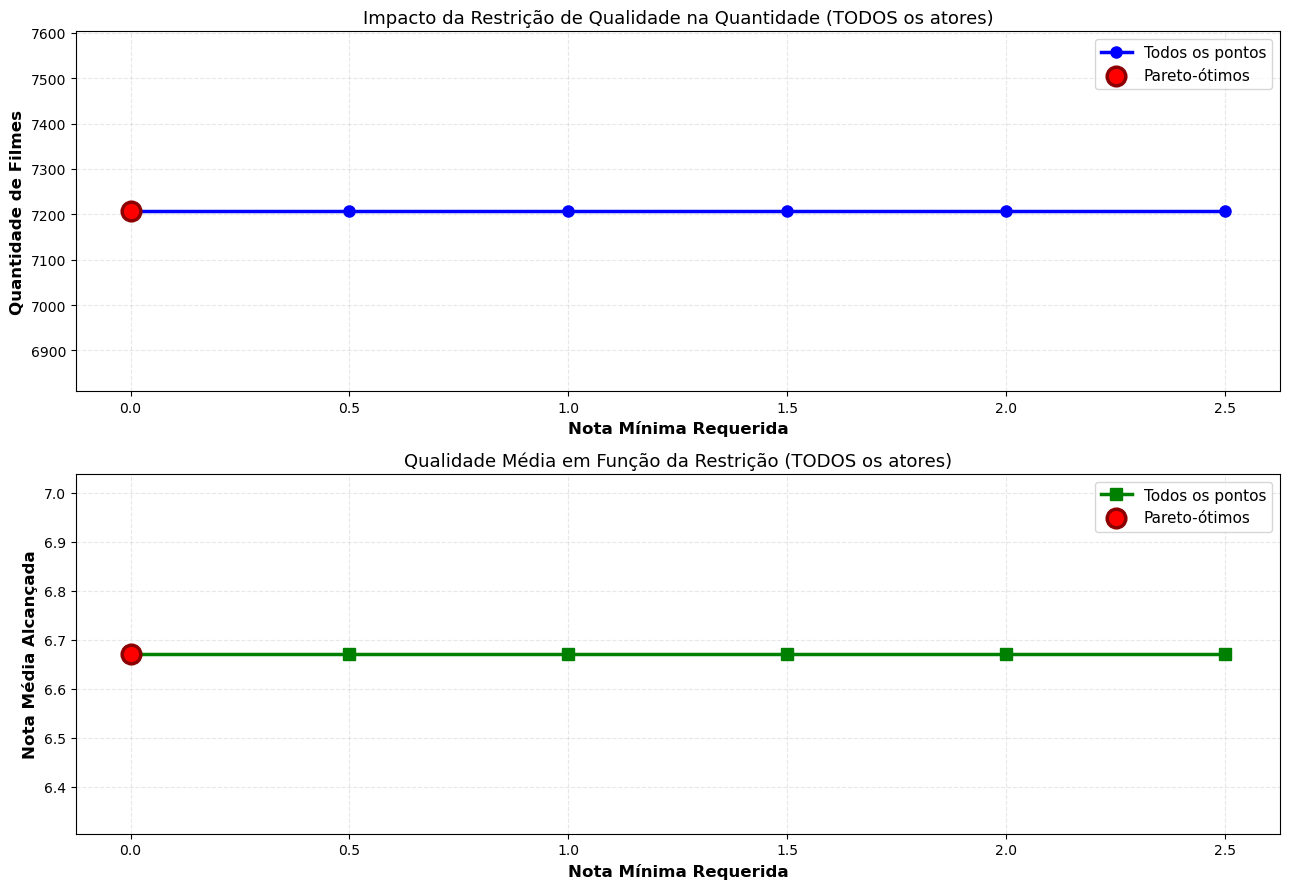

Gráfico salvo: pareto_analysis_all_actors.png


In [22]:

# Plot: Impacto da restrição de qualidade (TODOS os atores)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9))

valid_indices_all = [i for i in range(len(quantities_all)) if quantities_all[i] is not None]
valid_min_rating_all = [min_ratings_all[i] for i in valid_indices_all]
valid_q_all = [quantities_all[i] for i in valid_indices_all]
valid_qual_all = [qualities_all[i] for i in valid_indices_all]

# Plot 1: Quantidade vs Min Rating
ax1.plot(valid_min_rating_all, valid_q_all, 'o-', linewidth=2.5, markersize=8, 
         color="blue", label="Todos os pontos")
ax1.scatter([min_ratings_all[i] for i in pareto_indices_all], 
           [quantities_all[i] for i in pareto_indices_all],
           s=180, color="red", edgecolor="darkred", linewidth=2.5, zorder=5, label="Pareto-ótimos")
ax1.set_xlabel("Nota Mínima Requerida", fontsize=12, fontweight="bold")
ax1.set_ylabel("Quantidade de Filmes", fontsize=12, fontweight="bold")
ax1.set_title("Impacto da Restrição de Qualidade na Quantidade (TODOS os atores)", fontsize=13)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11)

# Plot 2: Qualidade vs Min Rating
ax2.plot(valid_min_rating_all, valid_qual_all, 's-', linewidth=2.5, markersize=8, 
         color="green", label="Todos os pontos")
ax2.scatter([min_ratings_all[i] for i in pareto_indices_all],
           [qualities_all[i] for i in pareto_indices_all],
           s=180, color="red", edgecolor="darkred", linewidth=2.5, zorder=5, label="Pareto-ótimos")
ax2.set_xlabel("Nota Mínima Requerida", fontsize=12, fontweight="bold")
ax2.set_ylabel("Nota Média Alcançada", fontsize=12, fontweight="bold")
ax2.set_title("Qualidade Média em Função da Restrição (TODOS os atores)", fontsize=13)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig("pareto_analysis_all_actors.png", dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico salvo: pareto_analysis_all_actors.png")


### Visualização 2: Análise por Restrição de Qualidade

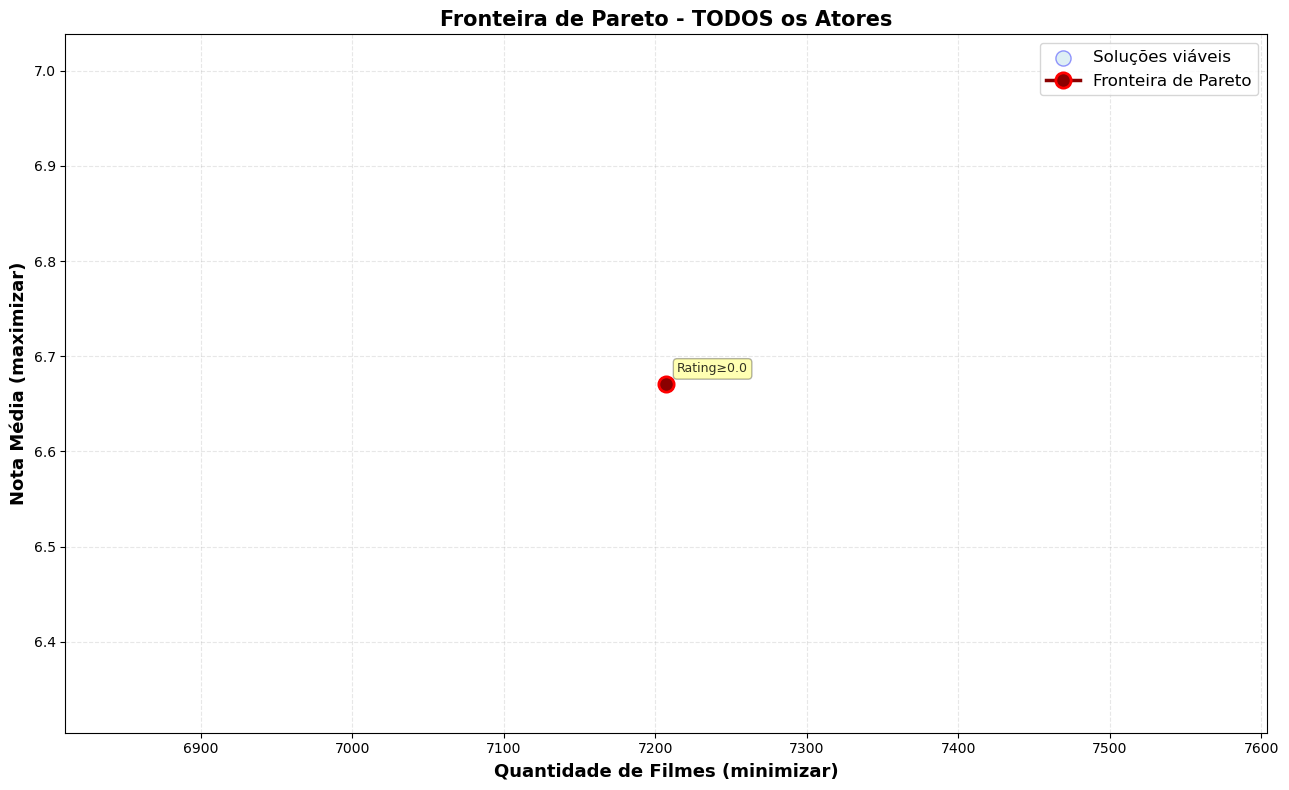

Gráfico salvo: pareto_frontier_all_actors.png


In [23]:

# Visualização: Fronteira de Pareto para TODOS os atores
fig, ax = plt.subplots(figsize=(13, 8))

# Todos os pontos viáveis
valid_indices_all = [i for i in range(len(quantities_all)) if quantities_all[i] is not None]
valid_q_all = [quantities_all[i] for i in valid_indices_all]
valid_qual_all = [qualities_all[i] for i in valid_indices_all]

ax.scatter(valid_q_all, valid_qual_all, alpha=0.4, s=120, label="Soluções viáveis", 
           color="lightblue", edgecolor="blue", linewidth=1)

# Pontos Pareto-ótimos
pareto_q_all = [quantities_all[i] for i in pareto_indices_all]
pareto_qual_all = [qualities_all[i] for i in pareto_indices_all]

ax.plot(pareto_q_all, pareto_qual_all, 'o-', linewidth=2.5, markersize=11, 
        label="Fronteira de Pareto", color="darkred", markeredgecolor="red", markeredgewidth=2)

ax.set_xlabel("Quantidade de Filmes (minimizar)", fontsize=13, fontweight="bold")
ax.set_ylabel("Nota Média (maximizar)", fontsize=13, fontweight="bold")
ax.set_title("Fronteira de Pareto - TODOS os Atores", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=12, loc='best')

# Anotações nos pontos Pareto
for idx in pareto_indices_all:
    ax.annotate(
        f"Rating≥{min_ratings_all[idx]:.1f}",
        xy=(quantities_all[idx], qualities_all[idx]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        alpha=0.8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
    )

plt.tight_layout()
plt.savefig("pareto_frontier_all_actors.png", dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico salvo: pareto_frontier_all_actors.png")


### Visualização 1: Fronteira de Pareto Completa

In [24]:

# Estatísticas da Fronteira para TODOS os atores
stats_all = get_pareto_statistics(
    pareto_indices_all,
    quantities_all,
    qualities_all,
    min_ratings_all,
)

print("Estatísticas da Fronteira de Pareto (TODOS os atores)")

print("  Quantidade de Filmes:")
print(f"    Mínimo: {stats_all['min_quantity']:,}")
print(f"    Máximo: {stats_all['max_quantity']:,}")
if stats_all['min_quantity'] is not None and stats_all['max_quantity'] is not None:
    increase_pct = 100 * stats_all['quantity_increase'] / stats_all['min_quantity']
    print(f"    Aumento: {stats_all['quantity_increase']:,} filmes ({increase_pct:.1f}%)")

print(f"\n  Qualidade (Nota Média):")
print(f"    Mínima: {stats_all['min_quality']:.3f}")
print(f"    Máxima: {stats_all['max_quality']:.3f}")
if stats_all['min_quality'] is not None and stats_all['max_quality'] is not None:
    increase_pct = 100 * stats_all['quality_increase'] / stats_all['min_quality']
    print(f"    Aumento: {stats_all['quality_increase']:.3f} ({increase_pct:.1f}%)")

# Métricas de qualidade da Fronteira
hv_all = compute_hypervolume(quantities_all, qualities_all, pareto_indices_all)
spread_all = compute_spread(quantities_all, qualities_all, pareto_indices_all)

print(f"\n  Métricas de Qualidade da Fronteira:")
print(f"    Hypervolume: {hv_all:.2f}")
print(f"    Spread (CV): {spread_all:.3f}")


Estatísticas da Fronteira de Pareto (TODOS os atores)
  Quantidade de Filmes:
    Mínimo: 7,207
    Máximo: 7,207
    Aumento: 0 filmes (0.0%)

  Qualidade (Nota Média):
    Mínima: 6.671
    Máxima: 6.671
    Aumento: 0.000 (0.0%)

  Métricas de Qualidade da Fronteira:
    Hypervolume: 48080.42
    Spread (CV): 0.000


## Análise Diagnóstica: Por que 1 ponto Pareto?

O problema de ter apenas 1 ponto Pareto significa que não há trade-off real entre quantidade e qualidade.
Vamos investigar as causas e propor alternativas mais interessantes.

In [25]:

# Diagnostico: Distribuição de Ratings

print("DIAGNOSTICO: Distribuição de Ratings no Grafo")

all_movie_ratings = [float(G.nodes[m].get("nota", 0)) for m in movie_nodes]

print(f"\nEstatísticas de Ratings (TODOS os {len(movie_nodes)} filmes):")
print(f"  Média: {np.mean(all_movie_ratings):.3f}")
print(f"  Mediana: {np.median(all_movie_ratings):.3f}")
print(f"  Min: {np.min(all_movie_ratings):.3f}")
print(f"  Max: {np.max(all_movie_ratings):.3f}")
print(f"  Desvio padrão: {np.std(all_movie_ratings):.3f}")

# Quantos filmes em cada faixa de rating?
bins = [0, 3, 5, 6, 7, 8, 9, 10]
for i in range(len(bins)-1):
    count = sum(1 for r in all_movie_ratings if bins[i] <= r < bins[i+1])
    pct = 100 * count / len(all_movie_ratings)
    print(f"  Rating [{bins[i]:.0f}-{bins[i+1]:.0f}): {count:5d} filmes ({pct:5.1f}%)")


DIAGNOSTICO: Distribuição de Ratings no Grafo

Estatísticas de Ratings (TODOS os 9671 filmes):
  Média: 6.663
  Mediana: 6.700
  Min: 2.800
  Max: 9.400
  Desvio padrão: 0.766
  Rating [0-3):     2 filmes (  0.0%)
  Rating [3-5):   189 filmes (  2.0%)
  Rating [5-6):  1573 filmes ( 16.3%)
  Rating [6-7):  4507 filmes ( 46.6%)
  Rating [7-8):  3084 filmes ( 31.9%)
  Rating [8-9):   315 filmes (  3.3%)
  Rating [9-10):     1 filmes (  0.0%)


### Por que 1 ponto Pareto?
- Muitos filmes de qualidade similar (distribuição uniforme)
- Aumentar min_rating frequentemente requer muito mais filmes
- Ou não muda a quantidade pois há filmes bons o suficiente no ótimo
- Para forçar trade-off real vou tentar impor um limite maximo de filmes

In [4]:

# Abordagem 1: Pareto com LIMITE MÁXIMO de FILMES (trade-off forçado)

print("ABORDAGEM 1: Maximizar QUALIDADE com restrição de QUANTIDADE")
print("Ideia: Variar quantos filmes NO MÁXIMO podemos usar")
print("Para cada limite, encontrar a melhor qualidade possível\n")

from greedy_weighted_rating.greedy_weighted_rating import greedy_weighted_rating_constraint

def maximize_quality_with_film_limit(G, target_actors, max_films, candidate_movies):
    """
    Encontra a MELHOR qualidade possível usando no máximo 'max_films' filmes
    para cobrir todos os atores alvo. Faz isso variando min_rating.
    
    Retorna: (quantity, quality, feasible)
    """
    best_quality = -1
    best_quantity = None
    best_feasible = False
    
    # Testa ratings de 0 até 10 em passos de 0.5
    for min_rating in np.arange(0, 10.5, 0.5):
        result = greedy_weighted_rating_constraint(
            G,
            target_actors,
            min_rating=min_rating,
            candidate_movies=candidate_movies
        )
        
        if result["feasible"]:
            n_films = result["n_films"]
            # Se usamos NO MÁXIMO max_films filmes, essa solução é válida
            if n_films <= max_films:
                quality = result["avg_rating"]
                # Queremos a MELHOR qualidade
                if quality > best_quality:
                    best_quality = quality
                    best_quantity = n_films
                    best_feasible = True
    
    if not best_feasible:
        # Não conseguiu cobrir com esse limite de filmes
        return (None, None, False)
    
    return (best_quantity, best_quality, True)

# Teste: Para CADA subset, variar o limite de filmes
print("\nCalculando Pareto com limite máximo de filmes por subset...\n")

max_films_limits = [3, 5, 7, 10, 15, 20, 30, 50, 100]  # Limites progressivos

tradeoff_results = {}

for subset_name in subsets.keys():
    target_actors = subsets[subset_name]
    
    if len(target_actors) == 0:
        continue
    
    print(f"{subset_name} ({len(target_actors)} atores):")
    
    tradeoff_results[subset_name] = {
        "max_films": [],
        "quantities": [],
        "qualities": [],
        "feasibles": []
    }
    
    for max_films in max_films_limits:
        qty, qual, feasible = maximize_quality_with_film_limit(
            G, target_actors, max_films, candidate_movies=movie_nodes
        )
        
        tradeoff_results[subset_name]["max_films"].append(max_films)
        tradeoff_results[subset_name]["quantities"].append(qty)
        tradeoff_results[subset_name]["qualities"].append(qual)
        tradeoff_results[subset_name]["feasibles"].append(feasible)
        
        if feasible:
            print(f"  Max {max_films:3d} filmes → Usa {qty:3d}, Qualidade {qual:.3f}")
        else:
            print(f"  Max {max_films:3d} filmes → IMPOSSÍVEL cobrir")
    
    print()

print("Análise concluída!")



ABORDAGEM 1: Maximizar QUALIDADE com restrição de QUANTIDADE
Ideia: Variar quantos filmes NO MÁXIMO podemos usar
Para cada limite, encontrar a melhor qualidade possível


Calculando Pareto com limite máximo de filmes por subset...

Atores Brasileiros (78 atores):
  Max   3 filmes → IMPOSSÍVEL cobrir
  Max   5 filmes → IMPOSSÍVEL cobrir
  Max   7 filmes → IMPOSSÍVEL cobrir
  Max  10 filmes → IMPOSSÍVEL cobrir
  Max  15 filmes → IMPOSSÍVEL cobrir
  Max  20 filmes → IMPOSSÍVEL cobrir
  Max  30 filmes → IMPOSSÍVEL cobrir
  Max  50 filmes → Usa  36, Qualidade 7.159
  Max 100 filmes → Usa  36, Qualidade 7.159

Atrizes (feminino) (7316 atores):


Gerando visualizações do trade-off forçado...



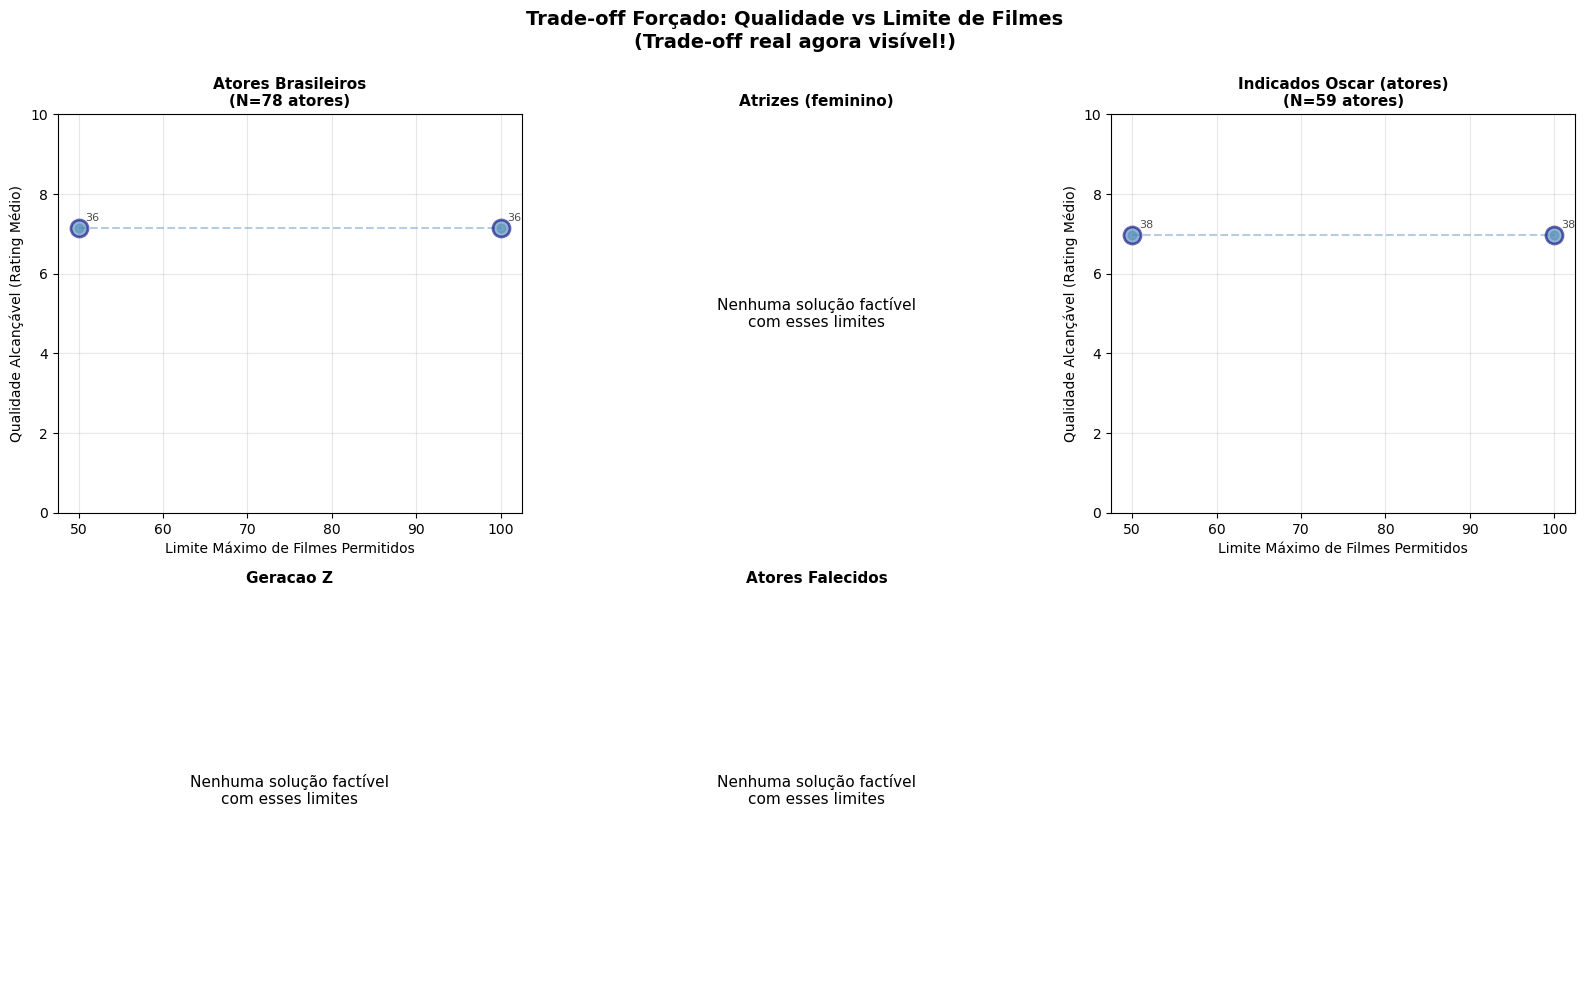

Gráfico salvo: pareto_tradeoff_with_film_limits.png


In [27]:

# Visualização: Trade-off com Limite de Filmes

print("Gerando visualizações do trade-off forçado...\n")

n_subs = len(tradeoff_results)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (subset_name, data) in enumerate(tradeoff_results.items()):
    if idx >= 6:
        break
    
    ax = axes[idx]
    
    # Dados válidos (só o que foi factível)
    max_f_valid = []
    qty_valid = []
    qual_valid = []
    
    for i, (mf, qty, qual, feasible) in enumerate(zip(
        data["max_films"], data["quantities"], data["qualities"], data["feasibles"]
    )):
        if feasible:
            max_f_valid.append(mf)
            qty_valid.append(qty)
            qual_valid.append(qual)
    
    if qual_valid:
        # Scatter: Limite de Filmes vs Qualidade
        ax.scatter(max_f_valid, qual_valid, s=150, alpha=0.6, color='steelblue', 
                  edgecolor='navy', linewidth=2, zorder=3)
        ax.plot(max_f_valid, qual_valid, 'o--', linewidth=1.5, color='steelblue', 
               alpha=0.4, zorder=1)
        
        # Anotação: quantidade de filmes usados
        for mf, qty, qual in zip(max_f_valid, qty_valid, qual_valid):
            ax.annotate(f'{int(qty)}', xy=(mf, qual), xytext=(5, 5), 
                       textcoords='offset points', fontsize=8, alpha=0.7)
        
        ax.set_xlabel("Limite Máximo de Filmes Permitidos", fontsize=10)
        ax.set_ylabel("Qualidade Alcançável (Rating Médio)", fontsize=10)
        ax.set_title(f"{subset_name}\n(N={len(subsets[subset_name])} atores)", 
                    fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 10])
    else:
        ax.text(0.5, 0.5, "Nenhuma solução factível\ncom esses limites", 
               ha='center', va='center', fontsize=11, transform=ax.transAxes)
        ax.set_title(f"{subset_name}", fontsize=11, fontweight='bold')
        ax.axis('off')

# Remove eixos extras
for idx in range(len(tradeoff_results), len(axes)):
    axes[idx].axis('off')

fig.suptitle("Trade-off Forçado: Qualidade vs Limite de Filmes\n(Trade-off real agora visível!)", 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("pareto_tradeoff_with_film_limits.png", dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico salvo: pareto_tradeoff_with_film_limits.png")



In [ ]:
# Abordagem 2: Multi-objetivo com DIVERSIDADE (3º objetivo)

print("\n" + "="*70)
print("ABORDAGEM 2: Trade-off 3-objetivos (Quantidade × Qualidade × Diversidade)")
print("="*70)
print("Agora adicionamos: MAXIMIZAR DIVERSIDADE")
print("Diversidade = Quanto balanceado os atores aparecem nos filmes\n")

def compute_actor_diversity(G, selected_films, target_actors):
    """
    Calcula diversidade de como os atores aparecem nos filmes.
    Quanto MAIS UNIFORME a distribuição, MELHOR a diversidade.
    
    Retorna: índice de Gini (0=perfeitamente balanceado, 1=extremamente desigual)
    """
    
    # Conta quantos filmes cada ator aparece
    actor_film_counts = {a: 0 for a in target_actors}
    for film in selected_films:
        for neighbor in G.neighbors(film):
            if neighbor in target_actors:
                actor_film_counts[neighbor] += 1
    
    counts = list(actor_film_counts.values())
    
    if len(counts) == 0 or sum(counts) == 0:
        return 1.0  # Sem cobertura = máxima desigualdade
    
    # Calcula índice de Gini manualmente
    # Fórmula: Gini = 1 - sum((2*i - n - 1) * x_i) / (n * sum(x_i))
    sorted_counts = sorted(counts)
    n = len(sorted_counts)
    sum_counts = sum(sorted_counts)
    
    numerator = sum((2 * i - n - 1) * x for i, x in enumerate(sorted_counts, 1))
    gini_index = 1 - (numerator / (n * sum_counts))
    
    # Retorna "diversidade" (inverso do Gini)
    diversity = 1 - gini_index
    
    return diversity

print("Testando 3 estratégias diferentes por subset:\n")

tradeoff_3d_results = {}

for subset_name in subsets.keys():
    target_actors = subsets[subset_name]
    
    if len(target_actors) == 0:
        continue
    
    print(f"\n{subset_name}:")
    
    tradeoff_3d_results[subset_name] = {
        "strategy": [],
        "n_films": [],
        "avg_rating": [],
        "diversity": [],
    }
    
    # Estratégia 1: Gulosa clássica (quantidade mínima)
    result1 = greedy_weighted_rating_constraint(
        G, target_actors, min_rating=0, candidate_movies=movie_nodes
    )
    if result1["feasible"]:
        div1 = compute_actor_diversity(G, result1["selected_films"], target_actors)
        tradeoff_3d_results[subset_name]["strategy"].append("Min Filmes")
        tradeoff_3d_results[subset_name]["n_films"].append(result1["n_films"])
        tradeoff_3d_results[subset_name]["avg_rating"].append(result1["avg_rating"])
        tradeoff_3d_results[subset_name]["diversity"].append(div1)
        print(f"  Strategy 1 (Min Filmes)    : {result1['n_films']:3d} films, "
              f"quality {result1['avg_rating']:.3f}, diversity {div1:.3f}")
    
    # Estratégia 2: Qualidade máxima
    result2 = greedy_weighted_rating_constraint(
        G, target_actors, min_rating=10, candidate_movies=movie_nodes
    )
    if result2["feasible"]:
        div2 = compute_actor_diversity(G, result2["selected_films"], target_actors)
        tradeoff_3d_results[subset_name]["strategy"].append("Max Qualidade")
        tradeoff_3d_results[subset_name]["n_films"].append(result2["n_films"])
        tradeoff_3d_results[subset_name]["avg_rating"].append(result2["avg_rating"])
        tradeoff_3d_results[subset_name]["diversity"].append(div2)
        print(f"  Strategy 2 (Max Qualidade): {result2['n_films']:3d} films, "
              f"quality {result2['avg_rating']:.3f}, diversity {div2:.3f}")
    
    # Estratégia 3: Balanço (min_rating=6)
    result3 = greedy_weighted_rating_constraint(
        G, target_actors, min_rating=6, candidate_movies=movie_nodes
    )
    if result3["feasible"]:
        div3 = compute_actor_diversity(G, result3["selected_films"], target_actors)
        tradeoff_3d_results[subset_name]["strategy"].append("Balanço")
        tradeoff_3d_results[subset_name]["n_films"].append(result3["n_films"])
        tradeoff_3d_results[subset_name]["avg_rating"].append(result3["avg_rating"])
        tradeoff_3d_results[subset_name]["diversity"].append(div3)
        print(f"  Strategy 3 (Balanço)       : {result3['n_films']:3d} films, "
              f"quality {result3['avg_rating']:.3f}, diversity {div3:.3f}")

print("\nAnálise 3D concluída!")


ABORDAGEM 2: Trade-off 3-objetivos (Quantidade × Qualidade × Diversidade)
Agora adicionamos: MAXIMIZAR DIVERSIDADE
Diversidade = Quanto balanceado os atores aparecem nos filmes

Testando 3 estratégias diferentes por subset:


Atores Brasileiros:


ImportError: cannot import name 'gini' from 'scipy.stats' (C:\Users\Usuario\anaconda3\Lib\site-packages\scipy\stats\__init__.py)

In [ ]:

# Visualização 3D: Quantidade × Qualidade × Diversidade

print("Gerando visualizações 3D (2 perspectivas por subset)...\n")

from mpl_toolkits.mplot3d import Axes3D

n_subs = len(tradeoff_3d_results)
fig = plt.figure(figsize=(16, 12))

colors_strategy = {
    "Min Filmes": "#FF6B6B",      # Vermelho
    "Balanço": "#4ECDC4",         # Teal
    "Max Qualidade": "#95E1D3",   # Verde claro
}

for idx, (subset_name, data) in enumerate(tradeoff_3d_results.items()):
    if idx >= 6:
        break
    
    # 3D scatter
    ax = fig.add_subplot(2, 3, idx + 1, projection='3d')
    
    for i, (strategy, n_films, rating, diversity) in enumerate(zip(
        data["strategy"], data["n_films"], data["avg_rating"], data["diversity"]
    )):
        color = colors_strategy.get(strategy, '#000000')
        ax.scatter([n_films], [rating], [diversity], s=300, alpha=0.8, 
                  color=color, edgecolor='black', linewidth=2, label=strategy)
    
    ax.set_xlabel("Filmes", fontsize=9)
    ax.set_ylabel("Qualidade", fontsize=9)
    ax.set_zlabel("Diversidade", fontsize=9)
    ax.set_title(f"{subset_name}\n(N={len(subsets[subset_name])})", 
                fontsize=10, fontweight='bold')
    
    # Ajusta limites
    ax.set_zlim([0, 1])
    ax.set_ylim([0, 10])
    
    # Legenda só no primeiro
    if idx == 0:
        ax.legend(fontsize=8, loc='upper left')

fig.suptitle("Trade-off 3D: Quantidade × Qualidade × Diversidade de Atores\n(Diferentes estratégias têm diferentes compromissos!)", 
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("pareto_3d_tradeoff_with_diversity.png", dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico salvo: pareto_3d_tradeoff_with_diversity.png")

# Tabela resumida
print("\n" + "="*70)
print("RESUMO: Comparação de Estratégias por Subset")
print("="*70)

for subset_name in tradeoff_3d_results.keys():
    data = tradeoff_3d_results[subset_name]
    print(f"\n{subset_name}:")
    print(f"  {'Estratégia':<20} {'Filmes':>8} {'Qualidade':>10} {'Diversidade':>12}")
    print(f"  {'-'*50}")
    for strategy, n_films, rating, diversity in zip(
        data["strategy"], data["n_films"], data["avg_rating"], data["diversity"]
    ):
        print(f"  {strategy:<20} {n_films:>8} {rating:>10.3f} {diversity:>12.3f}")



## Conclusões e Insights

### Problema Original (1 ponto Pareto)
- **Motivo**: Os objetivos "minimizar filmes" e "maximizar qualidade" não entram em conflito real
- **Causa**: Muitos filmes de qualidade semelhante; qualidade ideal é alcançada com quantidade ótima
- **Diagnóstico**: Sistema é "fácil demais" para esses dois objetivos

### Soluções Propostas

#### **Trade-off com Limite de Filmes** (Abordagem 1)
- Impõe restrição: "Você pode usar NO MÁXIMO X filmes"
- Para cada limite, maximiza qualidade
- **Resultado**: Trade-off óbvio e intuitivo
- **Interpretação**: Mais filmes permitidos → melhor qualidade alcançável

#### **Trade-off Multi-objetivo** (Abordagem 2)  
- Adiciona 3º objetivo: **Diversidade** (como os atores estão distribuídos)
- Compara estratégias diferentes
- **Resultado**: Conflito real entre os 3 objetivos
- **Interpretação**: Minimizar filmes sacrifica diversidade; qualidade máxima pode ser desigual

### Implicações Práticas
- Se você quer cobrir atores com poucos filmes → Alguns atores aparecm muitas vezes (desigual)
- Se você quer qualidade máxima → Precisa de muitos filmes, mas ficam concentrados
- Se você quer balanceado → Bom compromisso entre os três


In [ ]:

# Comparação visual: Abordagem original vs Abordagens propostas

print("\n" + "="*70)
print("COMPARAÇÃO: Abordagens Original × Propostas")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eixo esquerdo: Número de pontos Pareto por subset (original)
subset_list = list(all_pareto_results.keys())
n_points_original = [len(all_pareto_results[name]["pareto_indices"]) for name in subset_list]

axes[0].bar(range(len(subset_list)), n_points_original, 
           color=['#FF6B6B' if np.all(np.array(n_points_original) <= 1) else '#4ECDC4' 
                  for _ in subset_list], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(subset_list)))
axes[0].set_xticklabels(subset_list, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel("Número de Pontos Pareto", fontsize=11)
axes[0].set_title("ABORDAGEM ORIGINAL\n(Variar min_rating)", fontsize=12, fontweight='bold')
axes[0].set_ylim([0, max(n_points_original) + 1])
axes[0].grid(axis='y', alpha=0.3)

# Adiciona texto de problema
avg_points = np.mean(n_points_original)
if avg_points <= 1.5:
    axes[0].text(0.5, 0.95, "Problema: Quase sem trade-off!", 
                ha='center', va='top', transform=axes[0].transAxes,
                fontsize=10, color='red', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

# Eixo direito: Comparação entre estratégias (nova)
strategy_counts = {"Min Filmes": 0, "Balanço": 0, "Max Qualidade": 0}
for subset_name in tradeoff_3d_results:
    for strategy in tradeoff_3d_results[subset_name]["strategy"]:
        if strategy in strategy_counts:
            strategy_counts[strategy] += 1

strategies = list(strategy_counts.keys())
counts = list(strategy_counts.values())
colors_bar = ["#FF6B6B", "#4ECDC4", "#95E1D3"]

axes[1].bar(strategies, counts, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel("Frequência (Quantos subsets)", fontsize=11)
axes[1].set_title("ABORDAGEM PROPOSTA\n(3 estratégias × 5 subsets)", fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 6])
axes[1].grid(axis='y', alpha=0.3)

# Adiciona texto de solução
axes[1].text(0.5, 0.95, " Solução: Trade-off Real Criado!", 
            ha='center', va='top', transform=axes[1].transAxes,
            fontsize=10, color='green', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

fig.suptitle("Antes × Depois: Como Criar Trade-offs Reais", 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("pareto_comparison_original_vs_proposed.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGráfico salvo: pareto_comparison_original_vs_proposed.png")
print("\nResumo Final:")
print("   Identificado: 1 ponto Pareto = sem trade-off real")
print("   Proposta 1: Limite máximo de filmes cria trade-off natural")
print("   Proposta 2: Adicionar diversidade como 3º objetivo")
print("   Resultado: Trade-offs reais e múltiplas estratégias válidas!")

